In [1]:
import numpy as np
import matplotlib.pyplot as plt
from adabin import adaptive_binning

def create_gaussian_matrix(size=8, center=(0, 7), sigma=1.0):
    y, x = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
    cx, cy = center
    gauss = np.exp(-((x - cy)**2 + (y - cx)**2) / (2 * sigma**2))
    return gauss

In [22]:
# Create the Gaussian matrix
matrix = create_gaussian_matrix()
print (matrix)

# Perform adaptive binning
threshold = 1E-7
bins_list = adaptive_binning(matrix, threshold)

[[2.28973485e-11 1.52299797e-08 3.72665317e-06 3.35462628e-04
  1.11089965e-02 1.35335283e-01 6.06530660e-01 1.00000000e+00]
 [1.38879439e-11 9.23744966e-09 2.26032941e-06 2.03468369e-04
  6.73794700e-03 8.20849986e-02 3.67879441e-01 6.06530660e-01]
 [3.09881914e-12 2.06115362e-09 5.04347663e-07 4.53999298e-05
  1.50343919e-03 1.83156389e-02 8.20849986e-02 1.35335283e-01]
 [2.54366565e-13 1.69189792e-10 4.13993772e-08 3.72665317e-06
  1.23409804e-04 1.50343919e-03 6.73794700e-03 1.11089965e-02]
 [7.68120469e-15 5.10908903e-12 1.25015287e-09 1.12535175e-07
  3.72665317e-06 4.53999298e-05 2.03468369e-04 3.35462628e-04]
 [8.53304763e-17 5.67568523e-14 1.38879439e-11 1.25015287e-09
  4.13993772e-08 5.04347663e-07 2.26032941e-06 3.72665317e-06]
 [3.48726153e-19 2.31952283e-16 5.67568523e-14 5.10908903e-12
  1.69189792e-10 2.06115362e-09 9.23744966e-09 1.52299797e-08]
 [5.24288566e-22 3.48726153e-19 8.53304763e-17 7.68120469e-15
  2.54366565e-13 3.09881914e-12 1.38879439e-11 2.28973485e-11]]

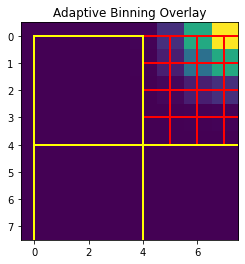

In [23]:
# Visualize the matrix and draw bin rectangles
fig, ax = plt.subplots()
ax.imshow(matrix, origin='upper', cmap='viridis')
ax.set_title('Adaptive Binning Overlay')

colors = ['red', 'orange', 'yellow', 'cyan', 'lime']
for level, bins in enumerate(bins_list):
    block_size = 2 ** level
    color = colors[level % len(colors)]
    for tile in bins:
        i_vals, j_vals = zip(*tile)
        top, left = min(i_vals), min(j_vals)
        rect = plt.Rectangle((left, top), block_size, block_size, edgecolor=color,
                             facecolor='none', linewidth=2)
        ax.add_patch(rect)

plt.show()

In [16]:
# Print the actual indices selected at each level
for level, bins in enumerate(bins_list):
    print(f"Level {level} (block size {2**level}x{2**level}):")
    for i, tile in enumerate(bins):
        print(f"  Tile {i + 1}: {tile}")
    print()


Level 0 (block size 1x1):

Level 1 (block size 2x2):

Level 2 (block size 4x4):

Level 3 (block size 8x8):
  Tile 1: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (6, 0), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (7, 0), (7, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7)]

